Загружаем датасет (я грузила напрямую через кеглю)

In [1]:
!pip install -q kaggle

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
import os
import zipfile
import pandas as pd

os.environ['KAGGLE_API_TOKEN'] = "XXXXXXXXXXXX"
!kaggle datasets download -d jsphyg/weather-dataset-rattle-package
with zipfile.ZipFile("weather-dataset-rattle-package.zip", "r") as zip_ref:
    zip_ref.extractall("weather_data")

df = pd.read_csv("weather_data/weatherAUS.csv")



Dataset URL: https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package
License(s): other
weather-dataset-rattle-package.zip: Skipping, found more recently modified local copy (use --force to force download)


Изучаем датасет

In [4]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [5]:
df.shape

(145460, 23)

In [6]:
df.info

<bound method DataFrame.info of               Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  \
0       2008-12-01   Albury     13.4     22.9       0.6          NaN   
1       2008-12-02   Albury      7.4     25.1       0.0          NaN   
2       2008-12-03   Albury     12.9     25.7       0.0          NaN   
3       2008-12-04   Albury      9.2     28.0       0.0          NaN   
4       2008-12-05   Albury     17.5     32.3       1.0          NaN   
...            ...      ...      ...      ...       ...          ...   
145455  2017-06-21    Uluru      2.8     23.4       0.0          NaN   
145456  2017-06-22    Uluru      3.6     25.3       0.0          NaN   
145457  2017-06-23    Uluru      5.4     26.9       0.0          NaN   
145458  2017-06-24    Uluru      7.8     27.0       0.0          NaN   
145459  2017-06-25    Uluru     14.9      NaN       0.0          NaN   

        Sunshine WindGustDir  WindGustSpeed WindDir9am  ... Humidity9am  \
0            NaN           W

In [7]:
colms = df.columns.tolist()
colms

['Date',
 'Location',
 'MinTemp',
 'MaxTemp',
 'Rainfall',
 'Evaporation',
 'Sunshine',
 'WindGustDir',
 'WindGustSpeed',
 'WindDir9am',
 'WindDir3pm',
 'WindSpeed9am',
 'WindSpeed3pm',
 'Humidity9am',
 'Humidity3pm',
 'Pressure9am',
 'Pressure3pm',
 'Cloud9am',
 'Cloud3pm',
 'Temp9am',
 'Temp3pm',
 'RainToday',
 'RainTomorrow']

In [8]:
df.describe().round(2)

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.00,144199.00,142199.00,82670.00,75625.00,135197.00,143693.00,142398.00,142806.00,140953.00,130395.00,130432.00,89572.00,86102.00,143693.00,141851.00
mean,12.19,23.22,2.36,5.47,7.61,40.04,14.04,18.66,68.88,51.54,1017.65,1015.26,4.45,4.51,16.99,21.68
std,6.40,7.12,8.48,4.19,3.79,13.61,8.92,8.81,19.03,20.80,7.11,7.04,2.89,2.72,6.49,6.94
min,-8.50,-4.80,0.00,0.00,0.00,6.00,0.00,0.00,0.00,0.00,980.50,977.10,0.00,0.00,-7.20,-5.40
25%,7.60,17.90,0.00,2.60,4.80,31.00,7.00,13.00,57.00,37.00,1012.90,1010.40,1.00,2.00,12.30,16.60
50%,12.00,22.60,0.00,4.80,8.40,39.00,13.00,19.00,70.00,52.00,1017.60,1015.20,5.00,5.00,16.70,21.10
75%,16.90,28.20,0.80,7.40,10.60,48.00,19.00,24.00,83.00,66.00,1022.40,1020.00,7.00,7.00,21.60,26.40
max,33.90,48.10,371.00,145.00,14.50,135.00,130.00,87.00,100.00,100.00,1041.00,1039.60,9.00,9.00,40.20,46.70


In [10]:
df.isnull().sum()

Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62790
Sunshine         69835
WindGustDir      10326
WindGustSpeed    10263
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
dtype: int64

In [11]:
empty_data = (df.isnull().mean() * 100).round()
types_data = df.dtypes.tolist()

print("Процент пропусков в данных:")
for i in range(len(empty_data)):
    print(f"{str(colms[i]):<15}{str(empty_data[i]):<10} {str(types_data[i]):<10}")


Процент пропусков в данных:
Date           0.0        object    
Location       0.0        object    
MinTemp        1.0        float64   
MaxTemp        1.0        float64   
Rainfall       2.0        float64   
Evaporation    43.0       float64   
Sunshine       48.0       float64   
WindGustDir    7.0        object    
WindGustSpeed  7.0        float64   
WindDir9am     7.0        object    
WindDir3pm     3.0        object    
WindSpeed9am   1.0        float64   
WindSpeed3pm   2.0        float64   
Humidity9am    2.0        float64   
Humidity3pm    3.0        float64   
Pressure9am    10.0       float64   
Pressure3pm    10.0       float64   
Cloud9am       38.0       float64   
Cloud3pm       41.0       float64   
Temp9am        1.0        float64   
Temp3pm        2.0        float64   
RainToday      2.0        object    
RainTomorrow   2.0        object    


Заметили, что пропусков много и их разное процентное соотношение

Будем делать:
1) Удаляем строки с пропусками целевой переменной, потому что они бесполезны RainTomorrow
2) Для категориальных признаков WindGustDir, WindDir9am, WindDir3pm создадим новый тип unknown и заменим все пропуски на него
3) Числовые признаки (температура, давление, влажность) будем заменять медианой распределения для конкретной локации 
4) Для признаков Sunshine, Evaporation, Cloud9am, Cloud3pm процент пропусков очень большой, поэтому создадим дополнительные признаки индекаторы, что в этих колонках был пропуск


In [12]:
init_rows = df.shape[0]
df = df.dropna(subset=['RainTomorrow'])
print(f"Удалено {init_rows - df.shape[0]} строк")

Удалено 3267 строк


In [13]:
wind_cols = ['WindGustDir','WindDir9am','WindDir3pm']

for c in wind_cols:
    df[c] = df[c].fillna('unknown')
print('Пропусков осталось в колонках:')
print(f"{wind_cols} - {df[wind_cols].isnull().sum()}")


Пропусков осталось в колонках:
['WindGustDir', 'WindDir9am', 'WindDir3pm'] - WindGustDir    0
WindDir9am     0
WindDir3pm     0
dtype: int64


In [14]:
add_indict = ['Sunshine', 'Evaporation', 'Cloud9am', 'Cloud3pm']
for c in add_indict:
    df[f"{c}_miss"] = df[c].isnull().astype(int)
for c in add_indict:
    df[c] = df.groupby('Location')[c].transform(lambda x: x.fillna(x.median()))
    df[c] = df[c].fillna(df[c].median())

print("Созданы признаки-индикаторы:")
print([f'{c}_miss' for c in add_indict])

Созданы признаки-индикаторы:
['Sunshine_miss', 'Evaporation_miss', 'Cloud9am_miss', 'Cloud3pm_miss']


In [15]:
num_cols = ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 
            'Pressure3pm', 'Temp9am', 'Temp3pm']

for col in num_cols:
    df[c] = df.groupby('Location')[c].transform(lambda x: x.fillna(x.median()))
    df[c] = df[c].fillna(df[c].median())

df['RainToday'] = df.groupby('Location')['RainToday'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'No'))



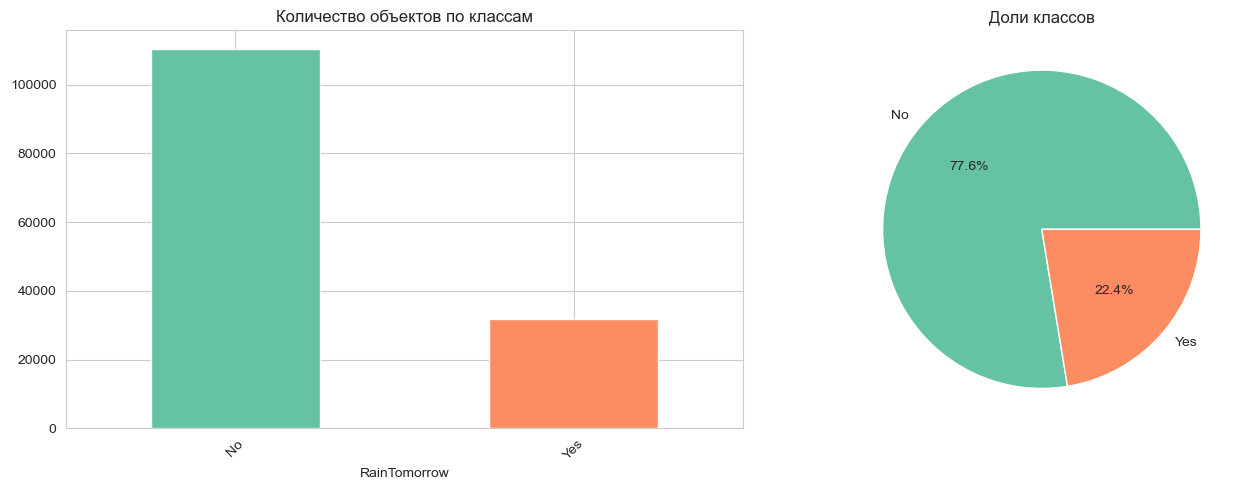

In [16]:
target_col = 'RainTomorrow'
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[target_col].value_counts().plot.bar(ax=axes[0], color=sns.color_palette('Set2'))
axes[0].set_title('Количество объектов по классам')
axes[0].tick_params(axis='x', rotation=45)

df[target_col].value_counts(normalize=True).plot.pie(ax=axes[1], autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_ylabel('')
axes[1].set_title('Доли классов')
plt.tight_layout()
plt.show()

Данные:
1) Временный, нужно сохранять последовательность
2) Сильный дисбаланс

Объединяем коррелированные признаки и оставляем только одно значение

In [17]:
def dew_point(temp, humidity):
    a = 17.27
    b = 237.7
    alpha = ((a * temp) / (b + temp)) + np.log(humidity / 100.0 + 1e-6)
    dew_point = (b * alpha) / (a - alpha)
    return dew_point
df['DewPoint9am'] = dew_point(df['Temp9am'], df['Humidity9am'])
df['DewPoint3pm'] = dew_point(df['Temp3pm'], df['Humidity3pm'])

df['CloudTempIndex9am'] = df['Temp9am'] * (1 - df['Cloud9am'] / 8)
df['CloudTempIndex3pm'] = df['Temp3pm'] * (1 - df['Cloud3pm'] / 8)

Преобразуем бинарные категориальные признаки в числовые

In [18]:
binary_mapping = {'Yes': 1, 'No': 0}
df['RainToday'] = df['RainToday'].map(binary_mapping)
df['RainTomorrow'] = df['RainTomorrow'].map(binary_mapping)

Удаляем лишние зависимые столбцы

In [19]:
to_drop = [
    'Date', 
    'Temp9am', 'Temp3pm', 
    'Humidity9am', 'Humidity3pm', 
    'Cloud9am', 'Cloud3pm'
]
df = df.drop(columns=to_drop)

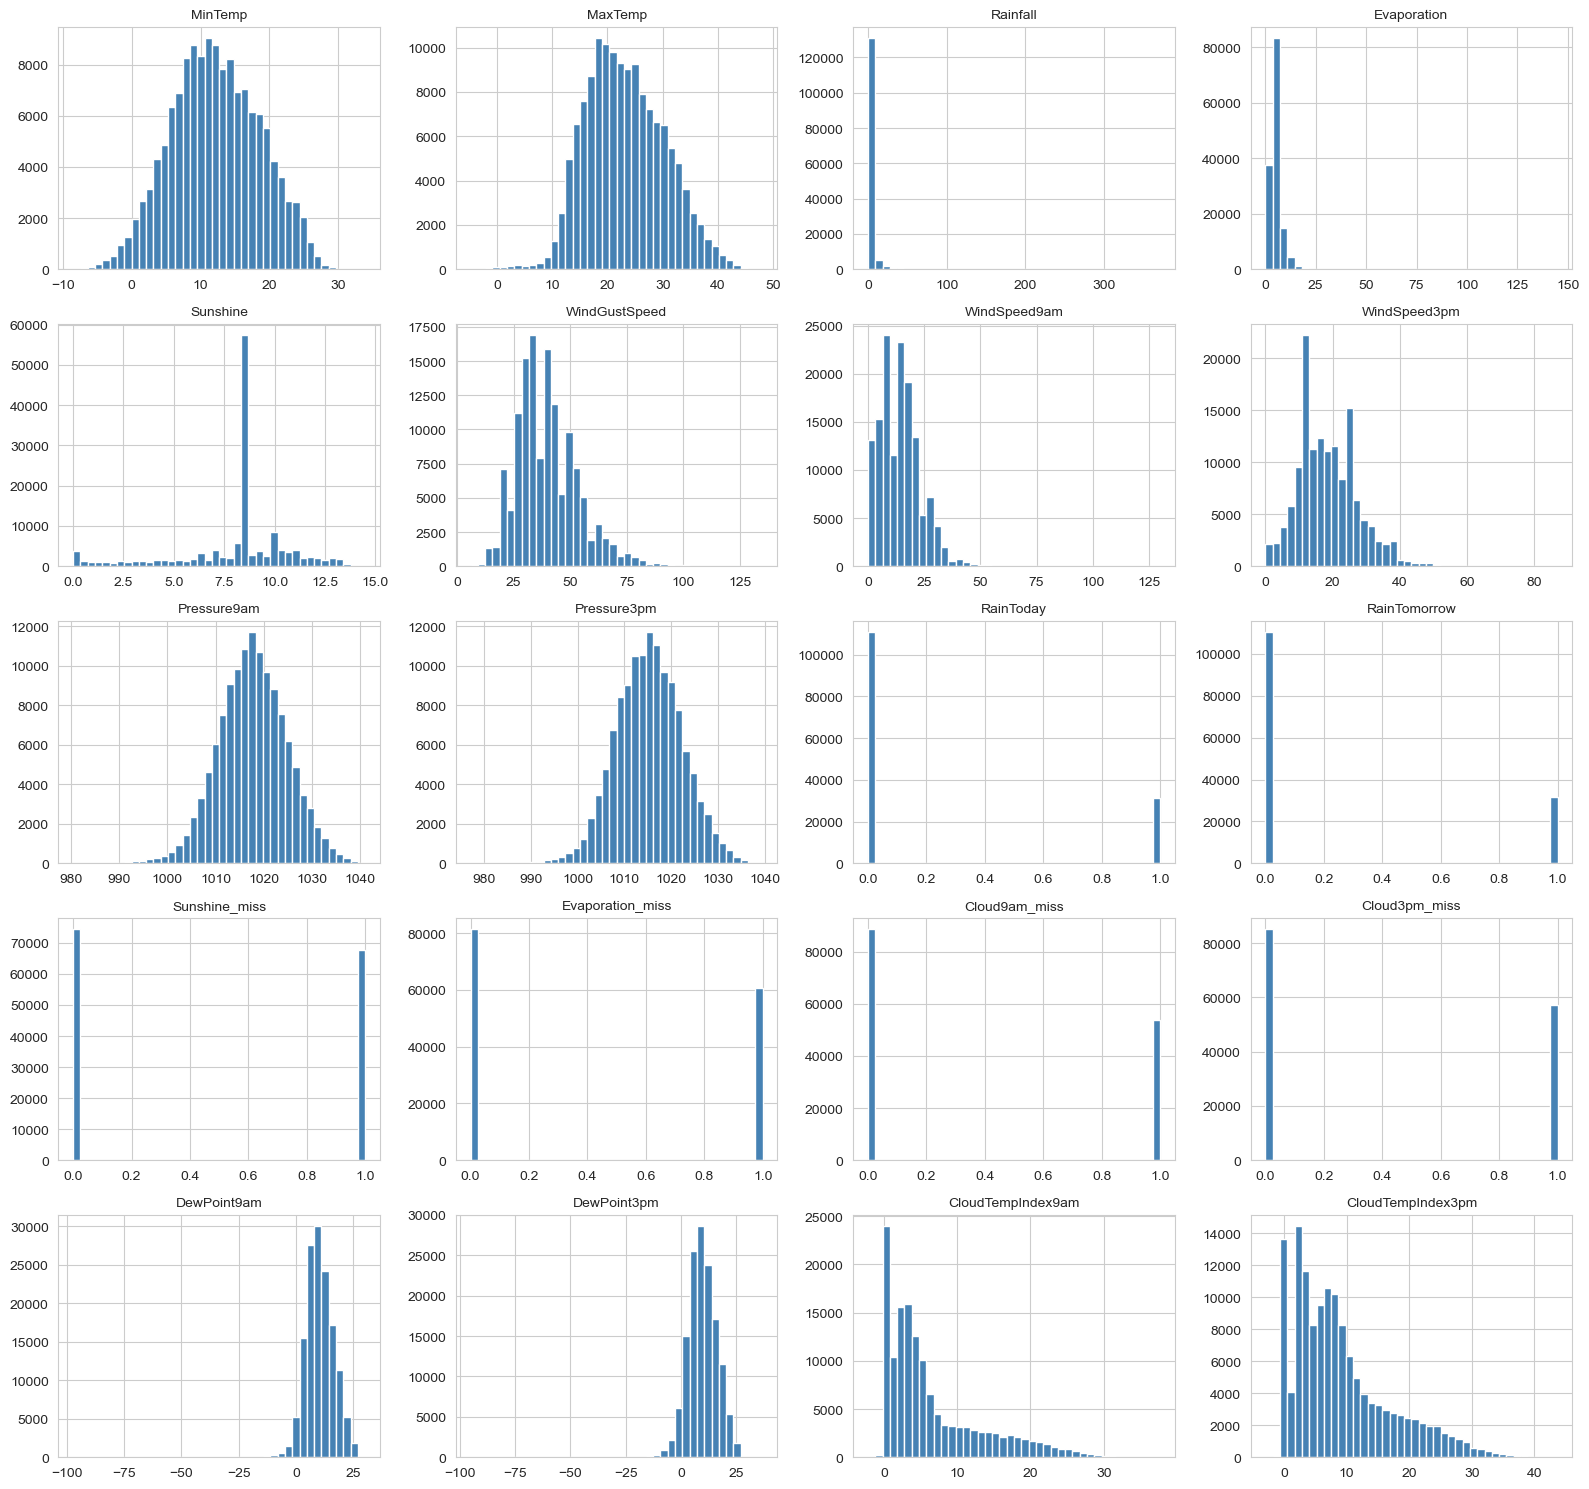

In [20]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

n_cols = len(numeric_cols)
n_rows = (n_cols + 3) // 4
fig, axes = plt.subplots(n_rows, 4, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[col].hist(bins=40, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

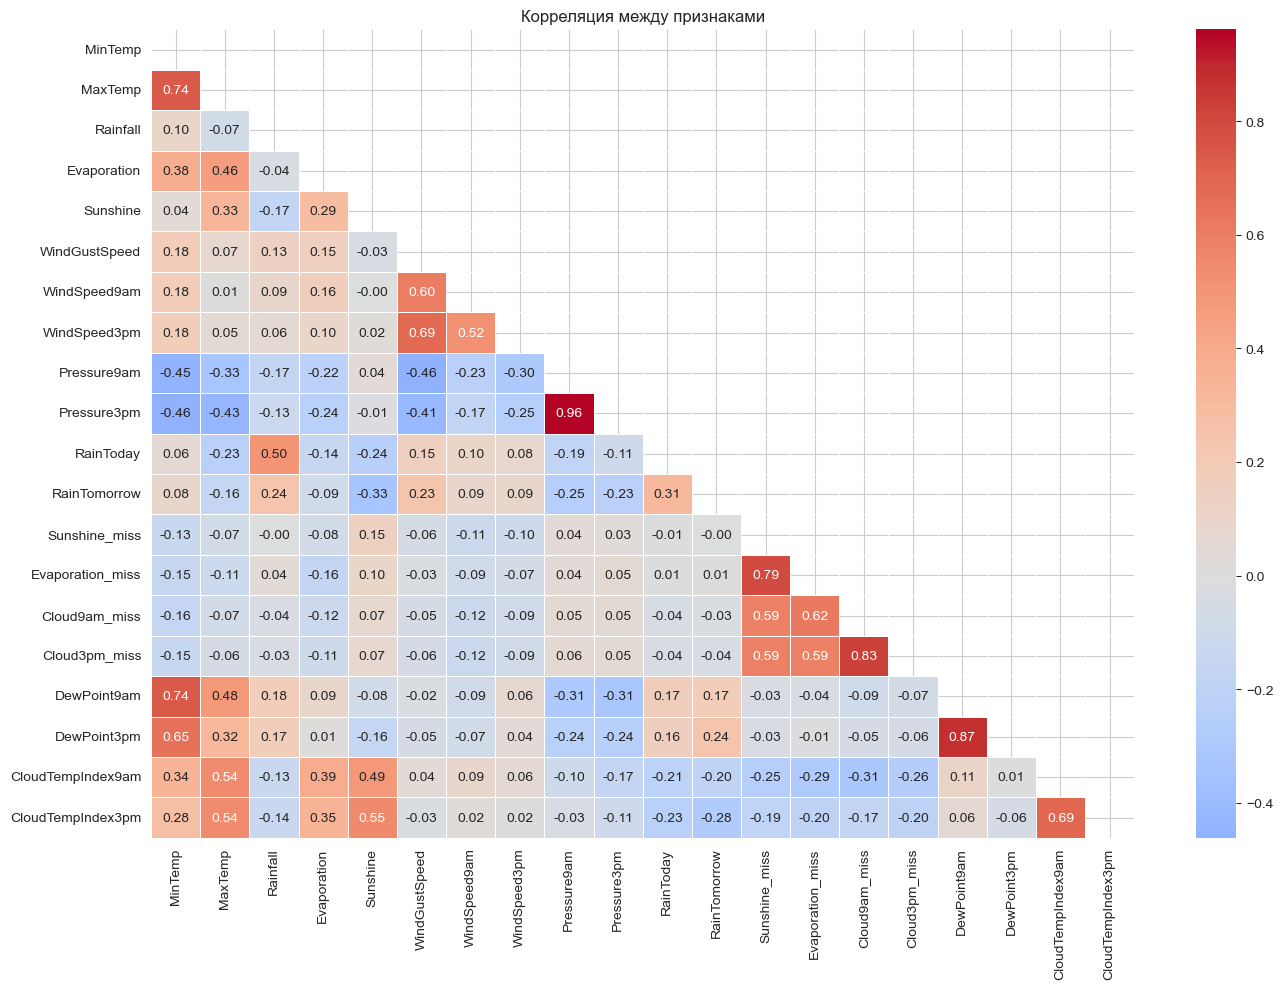

In [21]:
plt.figure(figsize=(14, 10))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Корреляция между признаками')
plt.tight_layout()
plt.show()

In [22]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

for c in numeric_cols:
    df[c] = df[c].fillna(df[c].median())

print("Оставшиеся пропуски ", df.isnull().sum().sum())


Оставшиеся пропуски  0


Убраны все пропуски и избавились от зависимости с помощью создания переменных DewPoint и CloudTempIndex

Переходим к созданию моделей (нормализацию и кодирование категориальных будем делать отдельно для каждой модели так как не для всех моделей необходимо делать и вообще мне так проще не путаться)

Данные временные, поэтому разбиваем на выборки согласно хронологии 
Тренировочная -- 65%
Валидационная -- 15%
Тестовая      -- 20%

In [23]:
import pandas as pd
import numpy as np

X_raw = df.drop(columns=['RainTomorrow'])
y_raw = df['RainTomorrow']

n = len(df)
train_end = int(n * 0.65)
val_end = int(n * 0.8)

X_train_raw, y_train = X_raw.iloc[:train_end].copy(), y_raw.iloc[:train_end]
X_val_raw, y_val = X_raw.iloc[train_end:val_end].copy(), y_raw.iloc[train_end:val_end]
X_test_raw, y_test = X_raw.iloc[val_end:].copy(), y_raw.iloc[val_end:]

print(f"Размер сырого Train: {X_train_raw.shape}, Val: {X_val_raw.shape}, Test: {X_test_raw.shape}")


Размер сырого Train: (92425, 23), Val: (21329, 23), Test: (28439, 23)


Кодировать признаки будем с помощью частотного кодирования, потому что слишком много вариантов в признаках направления ветра и тд...
Используя one-hot будет много (126 вроде), поэтому да считаем частоты
И нормализация для регрессии

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
                             accuracy_score, precision_score, recall_score, f1_score, log_loss)


X_train_lr = X_train_raw.copy()
X_val_lr = X_val_raw.copy()

#Частотное кодирование
cat_cols = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm']
for col in cat_cols:
    freq_map = X_train_lr[col].value_counts(normalize=True)
    X_train_lr[col] = X_train_lr[col].map(freq_map)
    X_val_lr[col] = X_val_lr[col].map(freq_map).fillna(0)


scaler_lr = StandardScaler()
X_train_lr_scaled = scaler_lr.fit_transform(X_train_lr)
X_val_lr_scaled = scaler_lr.transform(X_val_lr)


In [25]:
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train_lr_scaled, y_train)
y_pred_lr = lr_model.predict(X_val_lr_scaled)
y_proba_lr = lr_model.predict_proba(X_val_lr_scaled)[:, 1]

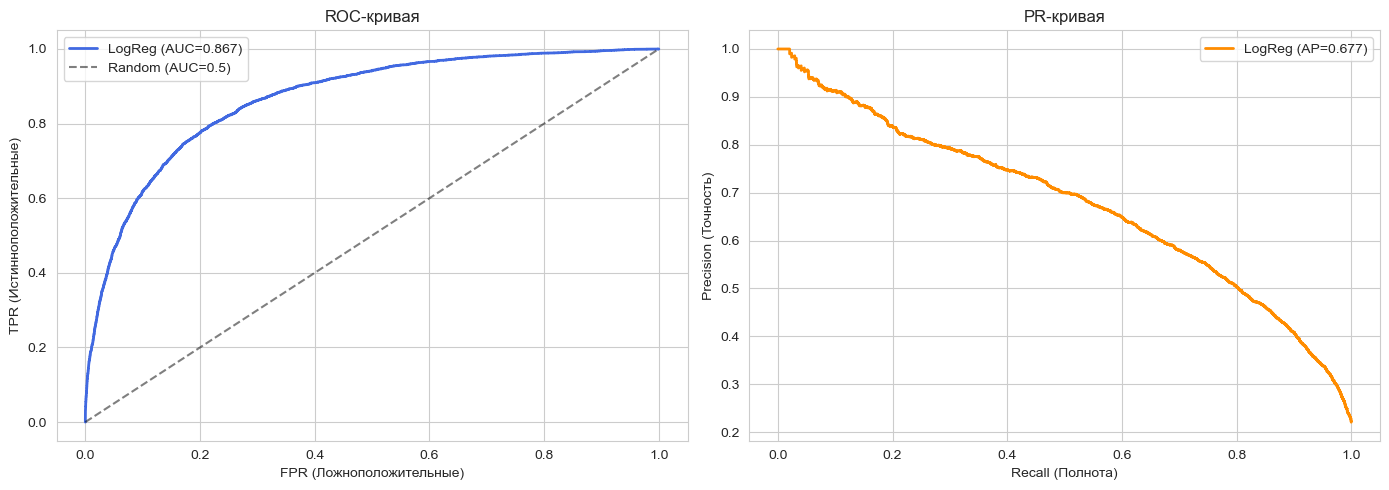

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_val, y_proba_lr)
axes[0].plot(fpr, tpr, linewidth=2, color='royalblue', label=f'LogReg (AUC={roc_auc_score(y_val, y_proba_lr):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC=0.5)')
axes[0].set_xlabel('FPR (Ложноположительные)')
axes[0].set_ylabel('TPR (Истинноположительные)')
axes[0].set_title('ROC-кривая')
axes[0].legend()

prec, rec, _ = precision_recall_curve(y_val, y_proba_lr)
ap = average_precision_score(y_val, y_proba_lr)
axes[1].plot(rec, prec, linewidth=2, color='darkorange', label=f'LogReg (AP={ap:.3f})')
axes[1].set_xlabel('Recall (Полнота)')
axes[1].set_ylabel('Precision (Точность)')
axes[1].set_title('PR-кривая')
axes[1].legend()

plt.tight_layout()
plt.show()

In [27]:
df_metrics_lr = pd.DataFrame({
    'Accuracy': [accuracy_score(y_val, y_pred_lr)],
    'Precision': [precision_score(y_val, y_pred_lr)],
    'Recall': [recall_score(y_val, y_pred_lr)],
    'F1': [f1_score(y_val, y_pred_lr)],
    'Log-Loss': [log_loss(y_val, y_proba_lr)],
    'ROC-AUC': [roc_auc_score(y_val, y_proba_lr)],
}, index=['LogReg (Validation)']).round(4)

display(df_metrics_lr)

,Accuracy,Precision,Recall,F1,Log-Loss,ROC-AUC
LogReg (Validation),0.8411,0.6571,0.5871,0.6201,0.3696,0.867


Дальше обучаем модель Лассо
Так же используем частотное кодирование и нормализацию для числовых данных

In [28]:
X_train_lasso = X_train_raw.copy()
X_val_lasso = X_val_raw.copy()

for col in cat_cols:
    freq_map = X_train_lasso[col].value_counts(normalize=True)
    X_train_lasso[col] = X_train_lasso[col].map(freq_map)
    X_val_lasso[col] = X_val_lasso[col].map(freq_map).fillna(0)

scaler_lasso = StandardScaler()
X_train_lasso_scaled = scaler_lasso.fit_transform(X_train_lasso)
X_val_lasso_scaled = scaler_lasso.transform(X_val_lasso)


In [29]:
lasso_model = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', C=0.1, random_state=42)
lasso_model.fit(X_train_lasso_scaled, y_train)
y_pred_lasso = lasso_model.predict(X_val_lasso_scaled)
y_proba_lasso = lasso_model.predict_proba(X_val_lasso_scaled)[:, 1]

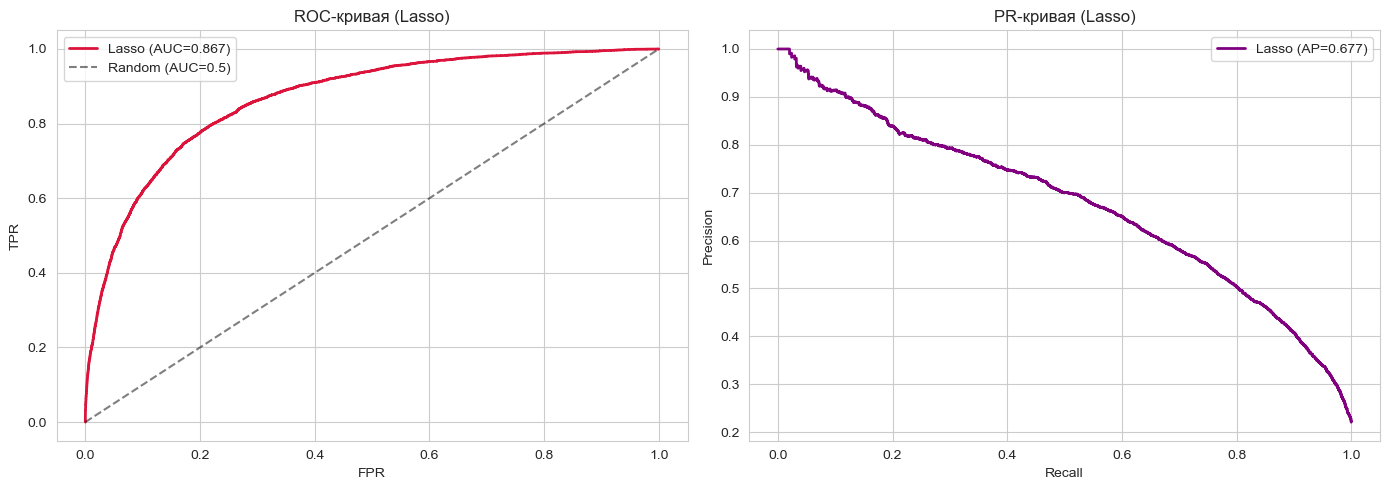

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_val, y_proba_lasso)
axes[0].plot(fpr, tpr, linewidth=2, color='crimson', label=f'Lasso (AUC={roc_auc_score(y_val, y_proba_lasso):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC=0.5)')
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].set_title('ROC-кривая (Lasso)')
axes[0].legend()

prec, rec, _ = precision_recall_curve(y_val, y_proba_lasso)
ap = average_precision_score(y_val, y_proba_lasso)
axes[1].plot(rec, prec, linewidth=2, color='purple', label=f'Lasso (AP={ap:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('PR-кривая (Lasso)')
axes[1].legend()

plt.tight_layout()
plt.show()


In [31]:
df_metrics_lasso = pd.DataFrame({
    'Accuracy': [accuracy_score(y_val, y_pred_lasso)],
    'Precision': [precision_score(y_val, y_pred_lasso)],
    'Recall': [recall_score(y_val, y_pred_lasso)],
    'F1': [f1_score(y_val, y_pred_lasso)],
    'Log-Loss': [log_loss(y_val, y_proba_lasso)],
    'ROC-AUC': [roc_auc_score(y_val, y_proba_lasso)],
}, index=['Lasso (Validation)']).round(4)

display(df_metrics_lasso)

,Accuracy,Precision,Recall,F1,Log-Loss,ROC-AUC
Lasso (Validation),0.8408,0.6554,0.5896,0.6208,0.3699,0.8672


Для дерева решений нормализацию не делаем

In [32]:
from sklearn.tree import DecisionTreeClassifier

X_train_tree = X_train_raw.copy()
X_val_tree = X_val_raw.copy()

for col in cat_cols:
    freq_map = X_train_tree[col].value_counts(normalize=True)
    X_train_tree[col] = X_train_tree[col].map(freq_map)
    X_val_tree[col] = X_val_tree[col].map(freq_map).fillna(0)

In [33]:
tree_model = DecisionTreeClassifier(max_depth=7, class_weight='balanced', random_state=42)
tree_model.fit(X_train_tree, y_train)
y_pred_tree = tree_model.predict(X_val_tree)
y_proba_tree = tree_model.predict_proba(X_val_tree)[:, 1]

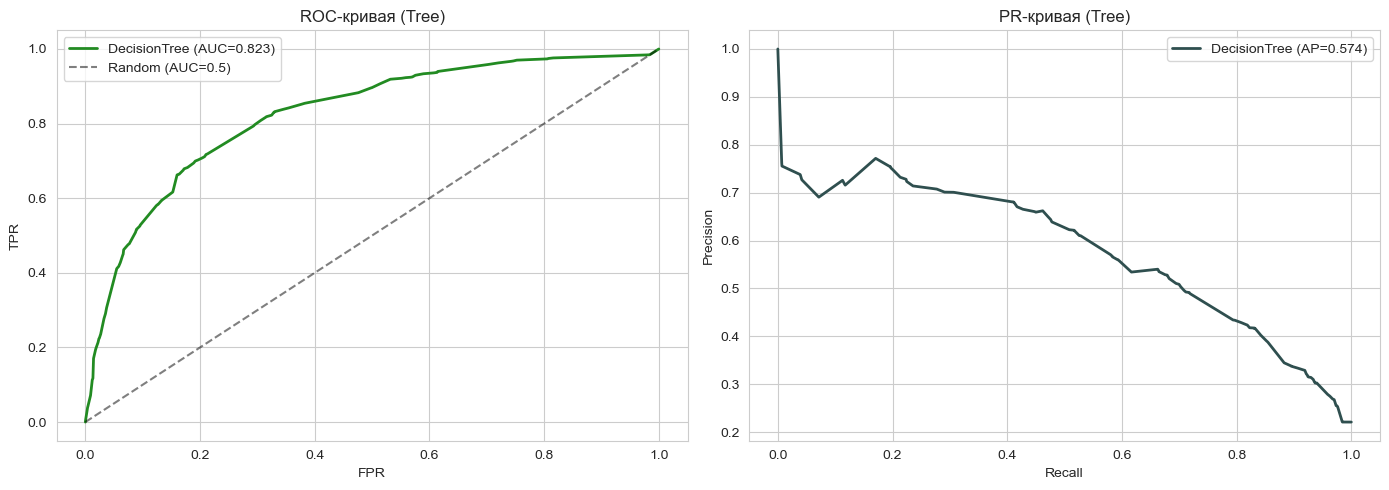

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_val, y_proba_tree)
axes[0].plot(fpr, tpr, linewidth=2, color='forestgreen', label=f'DecisionTree (AUC={roc_auc_score(y_val, y_proba_tree):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC=0.5)')
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].set_title('ROC-кривая (Tree)')
axes[0].legend()

prec, rec, _ = precision_recall_curve(y_val, y_proba_tree)
ap = average_precision_score(y_val, y_proba_tree)
axes[1].plot(rec, prec, linewidth=2, color='darkslategrey', label=f'DecisionTree (AP={ap:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('PR-кривая (Tree)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [35]:
df_metrics_tree = pd.DataFrame({
    'Accuracy': [accuracy_score(y_val, y_pred_tree)],
    'Precision': [precision_score(y_val, y_pred_tree)],
    'Recall': [recall_score(y_val, y_pred_tree)],
    'F1': [f1_score(y_val, y_pred_tree)],
    'Log-Loss': [log_loss(y_val, y_proba_tree)],
    'ROC-AUC': [roc_auc_score(y_val, y_proba_tree)],
}, index=['Decision Tree (Validation)']).round(4)

display(df_metrics_tree)

,Accuracy,Precision,Recall,F1,Log-Loss,ROC-AUC
Decision Tree (Validation),0.7849,0.5097,0.6964,0.5886,0.5838,0.8233


In [36]:
for col in cat_cols:
    freq_map = X_train_raw[col].value_counts(normalize=True)
    X_train_raw[col] = X_train_raw[col].map(freq_map)
    X_val_raw[col] = X_val_raw[col].map(freq_map).fillna(0)
    X_test_raw[col] = X_test_raw[col].map(freq_map).fillna(0)
print(X_train_raw[cat_cols].dtypes)

Location       float64
WindGustDir    float64
WindDir9am     float64
WindDir3pm     float64
dtype: object


Теперь будем использовать кросс-валидацию на пяти холдах

In [37]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from scipy.stats import uniform

tscv = TimeSeriesSplit(n_splits=5)

pipelines = {
    "Log-Reg": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
    ]),
    "Lasso": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', C=0.1, random_state=42))
    ]),
    "Dec-Tree": Pipeline([
        ('scaler', 'passthrough'),
        ('model', DecisionTreeClassifier(max_depth=7, class_weight='balanced', random_state=42))
    ])
}
cv_results_summary = []

for name, pipe in pipelines.items():
    scores = cross_validate(
        pipe, X_train_raw, y_train, 
        cv=tscv, 
        scoring={'roc_auc': 'roc_auc', 'log_loss': 'neg_log_loss'},
        n_jobs=-1
    )
    mean_auc = scores['test_roc_auc'].mean()
    mean_loss = -scores['test_log_loss'].mean() 
    cv_results_summary.append({'Модель': name, 'Mean ROC-AUC': mean_auc, 'Mean Log-Loss': mean_loss})

df_cv = pd.DataFrame(cv_results_summary).round(4)
display(df_cv)

,Модель,Mean ROC-AUC,Mean Log-Loss
0,Log-Reg,0.8330,0.5503
1,Lasso,0.8333,0.5488
2,Dec-Tree,0.7874,0.7223


Гиперпараметры - подбор рандомно

In [41]:
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', random_state=42))
])

param_distributions = {
    'model__C': uniform(0.001, 5.0)
}

random_search = RandomizedSearchCV(
    estimator=lasso_pipeline,
    param_distributions=param_distributions,
    n_iter=10,
    cv=tscv,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_raw, y_train)
print(f"Лучшие параметры: {random_search.best_params_}")
print(f"best mean ROC-AUC: {random_search.best_score_:.4f}")

best_cv_model = random_search.best_estimator_


Лучшие параметры: {'model__C': np.float64(0.2914180608409973)}
best mean ROC-AUC: 0.8331


In [42]:
num_cols = [col for col in X_train_raw.columns if col not in cat_cols]
ordered_features = num_cols + cat_cols

model_coefs = random_search.best_estimator_['model'].coef_[0]

feature_importance = pd.DataFrame({
    'Признак': ordered_features,
    'Вес': model_coefs,
    'модуль': np.abs(model_coefs)
}).sort_values(by='модуль', ascending=False)

display(feature_importance.head(10))

zeroed_features = feature_importance[feature_importance['Вес'] == 0]
print(f"Признаки, которые были обращены в ноль: {len(zeroed_features)} ")
if len(zeroed_features) > 0:
    display(zeroed_features['Признак'].tolist())
else:
    print("При данном значении C веса некоторых признаков близки к нулю, но полностью зануленных нет.")


,Признак,Вес,модуль
13,Cloud9am_miss,-1.142067,1.142067
20,WindGustDir,1.024798,1.024798
2,Rainfall,-0.884076,0.884076
12,Evaporation_miss,0.811117,0.811117
7,WindSpeed3pm,0.744930,0.744930
5,WindGustSpeed,-0.404122,0.404122
22,WindDir3pm,-0.388564,0.388564
18,CloudTempIndex3pm,-0.231057,0.231057
14,Cloud3pm_miss,0.219962,0.219962
11,Sunshine_miss,-0.219089,0.219089


Признаки, которые были обращены в ноль: 0 
При данном значении C веса некоторых признаков близки к нулю, но полностью зануленных нет.


Гипотеза 1:
Информациия о температуре, облачности и влажности зависимы, поэтому вместо отдельных признаков стоит использовать два, которые будут их линейной комбинацией DewPoint и CloudTempIndex

Гипотеза подтвердилась, создание новых признаков на основе старых позволило избавиться от линейной зависимости столбцов, при этом сохранила важную информацию о данных, модель считает что признак CloudTempIndex - входит в 10 самых важных

Гипотеза 2:
Логистическая регрессия будет лучше справляться с задачай предсказаний, чем деревья

Гипотеза подтвердилась, это объесняется тем, что для погодных данных невозможно подобрать универсальные предикаты, общие тенденции меняются от времени. 

Гипотеза 3:
Использование кросс-валидации на всем датасете ухудшит показатели модели, поскольку данные погоды имеют длитльные тенденции

Гипотеза подтвердилась, метрики при кросс-валидации ниже, это может быть связано с тем, что разное кол-во данных для разных лет, а также с тем что промежутки слишком маленькие и данные нестабильны. Поэтому нужно обучать модель на длительном промежутке времени.

Гипотеза 4:
Отсутствие признаков в столбцах Sunshine, Evaporation, Cloud9am, Cloud3pm несет много информации для 

Гипотеза подтвердилась, признаки отсутствия информации занимают 4 из 10 самых влиятельных признаков, что говорит о их важности и невозможности удаления, замены на среднее или медиану

Гипотеза 5:
Модель Лассо будет работать лучше логистической регрессии, поскольку в исходных данных много пропусков

Гипотеза не подтвердилась, модель Лассо не занулила не один признак, что означет, что регуляризация избыточна, классическая логистическая регрессия хорошо справляется с задачей.